# FINAL — Best Grid Load Model (all best choices combined)

**Group D — Grid Load Prediction**

This notebook consolidates the winning decision from every experiment into one clean, reproducible pipeline from **raw CSV → prediction**, then evaluates it with full visuals and saves it as the project's best model.

| Stage | Winning choice | Evidence |
| --- | --- | --- |
| Type cleaning | coerce junk text -> NaN | `00_data_understanding` |
| Range cleaning | null physically-impossible values | `00_data_understanding` |
| Imputation | **median** (robust, ≈KNN accuracy) | `imputation_01` |
| Features | cyclical + calendar flags + **interactions** + region one-hot | `feature_engineering_01` |
| Model | **GradientBoosting** (beat linear/RF in CV, less overfit than RF) | `02`, `model_02_cv`, `diagnostics_01` |
| Scaling | **none** (tree model is scale-invariant) | `scaling_01` |
| Hyperparameters | lr=0.1, depth=2, n_est=400, subsample=0.8, min_leaf=5 | `tuning_01` |
| Augmentation | none (no gain; data already sufficient) | `augmentation_01` |

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, joblib
sns.set_theme(style='whitegrid')
REPO = Path.cwd()
while not (REPO/'data').exists() and REPO != REPO.parent: REPO = REPO.parent
FIGS = REPO/'reports'/'figures'; FIGS.mkdir(parents=True, exist_ok=True)
print('repo:', REPO)

repo: /home/winzer/code/python/class/aion-gridload


## Step 1 — Load raw & clean (type + range + median impute), written inline

In [2]:
raw = pd.read_csv(REPO/'data'/'raw'/'Uganda_Grid_Load_Dataset.csv',
                  na_values=['N/A','NA','n/a','unknown','Unknown','###','?','-',''])
num_cols = ['Hour','DayOfWeek','Temperature_C','Humidity_pct','Rainfall_mm',
            'PopulationIndex','IndustrialIndex','SolarGenerationIndex','GridLoad_MW']
d = raw.drop(columns=['Record_ID'])
for c in num_cols:
    d[c] = pd.to_numeric(d[c], errors='coerce')          # junk text -> NaN
d['Region'] = d['Region'].astype('string').str.strip().str.title()
# range cleaning: physically-impossible values -> NaN
ranges = {'Hour':(0,23),'DayOfWeek':(0,6),'Temperature_C':(-10,55),'Humidity_pct':(0,100),
          'Rainfall_mm':(0,500),'PopulationIndex':(0,100),'IndustrialIndex':(0,100),
          'SolarGenerationIndex':(0,1),'GridLoad_MW':(0,5000)}
for c,(lo,hi) in ranges.items():
    d.loc[(d[c]<lo)|(d[c]>hi), c] = np.nan
d = d.dropna(subset=['GridLoad_MW']).reset_index(drop=True)  # can't use rows w/o target
for c in [c for c in num_cols if c!='GridLoad_MW']:
    d[c] = d[c].fillna(d[c].median())                    # median imputation
d['Region'] = d['Region'].fillna(d['Region'].mode()[0])
print('clean:', d.shape, '| missing:', int(d.isna().sum().sum()))

clean: (1489, 10) | missing: 0


## Step 2 — Feature engineering (winning set incl. interactions)

In [3]:
def make_features(frame):
    x = frame.copy()
    x['Hour_sin']=np.sin(2*np.pi*x['Hour']/24); x['Hour_cos']=np.cos(2*np.pi*x['Hour']/24)
    x['DoW_sin']=np.sin(2*np.pi*x['DayOfWeek']/7); x['DoW_cos']=np.cos(2*np.pi*x['DayOfWeek']/7)
    x['is_weekend']=(x['DayOfWeek']>=5).astype(int)
    x['is_daytime']=x['Hour'].between(6,18).astype(int)
    x['is_evening_peak']=x['Hour'].between(18,22).astype(int)
    x['Temp_x_Humidity']=x['Temperature_C']*x['Humidity_pct']
    x['Pop_x_Industrial']=x['PopulationIndex']*x['IndustrialIndex']
    x=pd.concat([x.drop(columns=['Region']),
                 pd.get_dummies(x['Region'],prefix='Region').astype(int)],axis=1)
    return x
feat = make_features(d)
y = feat['GridLoad_MW']; X = feat.drop(columns=['GridLoad_MW']).select_dtypes('number')
print('features:', X.shape[1])

features: 21


## Step 3 — Train the tuned GradientBoosting model (no scaling needed)

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             median_absolute_error, max_error)
PARAMS = dict(learning_rate=0.1, max_depth=2, n_estimators=400,
              subsample=0.8, min_samples_leaf=5, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
model = GradientBoostingRegressor(**PARAMS).fit(Xtr, ytr)
pred = model.predict(Xte)

## Step 4 — Evaluation: held-out test + 5-fold CV

In [5]:
def rmse(a,b): return np.sqrt(mean_squared_error(a,b))
metrics = {'RMSE':rmse(yte,pred),'MAE':mean_absolute_error(yte,pred),
           'MedAE':median_absolute_error(yte,pred),'MaxErr':max_error(yte,pred),
           'R2':r2_score(yte,pred),
           'MAPE%':float(np.mean(np.abs((yte-pred)/yte))*100)}
cv = KFold(5, shuffle=True, random_state=42)
cv_rmse = -cross_val_score(GradientBoostingRegressor(**PARAMS), X, y, cv=cv,
                           scoring='neg_root_mean_squared_error', n_jobs=-1)
print('5-fold CV RMSE: %.3f +/- %.3f' % (cv_rmse.mean(), cv_rmse.std()))
pd.Series(metrics).round(3).to_frame('test')

5-fold CV RMSE: 10.487 +/- 0.297


,test
RMSE,10.133
MAE,8.315
MedAE,7.580
MaxErr,31.714
R2,0.990
MAPE%,1.397


## Step 5 — Visuals

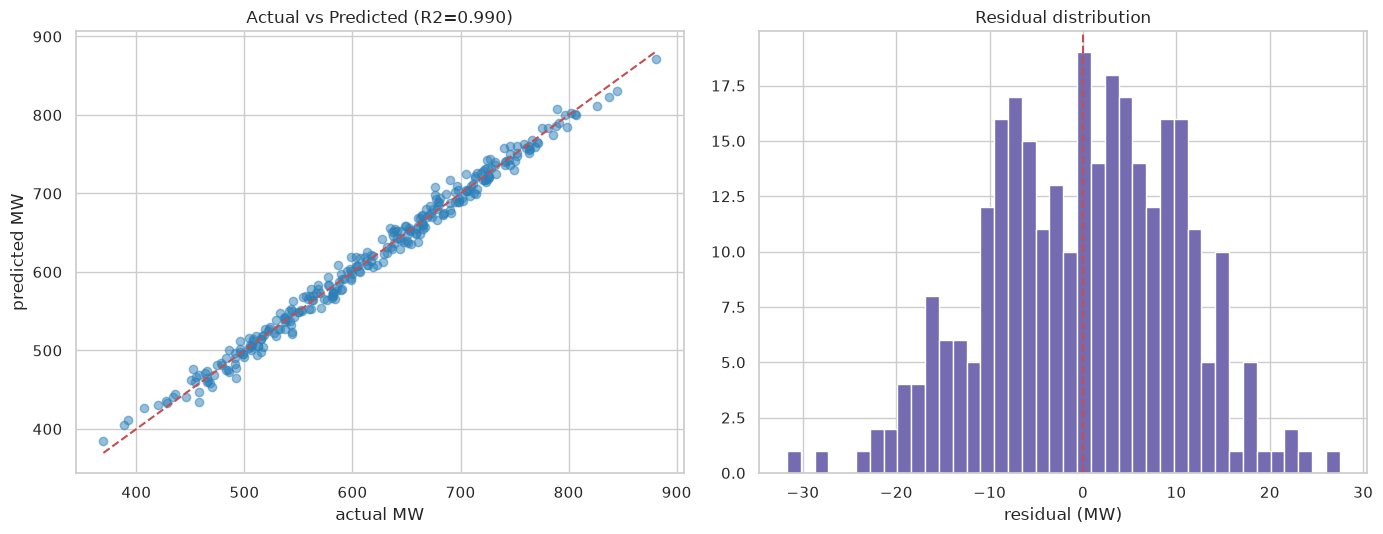

In [6]:
# (a) actual vs predicted
fig, ax = plt.subplots(1, 2, figsize=(14,5.5))
ax[0].scatter(yte, pred, alpha=.5, color='#2c7fb8')
lims=[min(yte.min(),pred.min()), max(yte.max(),pred.max())]
ax[0].plot(lims, lims, 'r--'); ax[0].set_xlabel('actual MW'); ax[0].set_ylabel('predicted MW')
ax[0].set_title(f'Actual vs Predicted (R2={metrics["R2"]:.3f})')
# (b) residual distribution
resid = yte - pred
ax[1].hist(resid, bins=40, color='#756bb1', edgecolor='white')
ax[1].axvline(0, color='r', ls='--'); ax[1].set_title('Residual distribution')
ax[1].set_xlabel('residual (MW)')
fig.tight_layout(); fig.savefig(FIGS/'final_actual_vs_pred.png', dpi=120); plt.show()

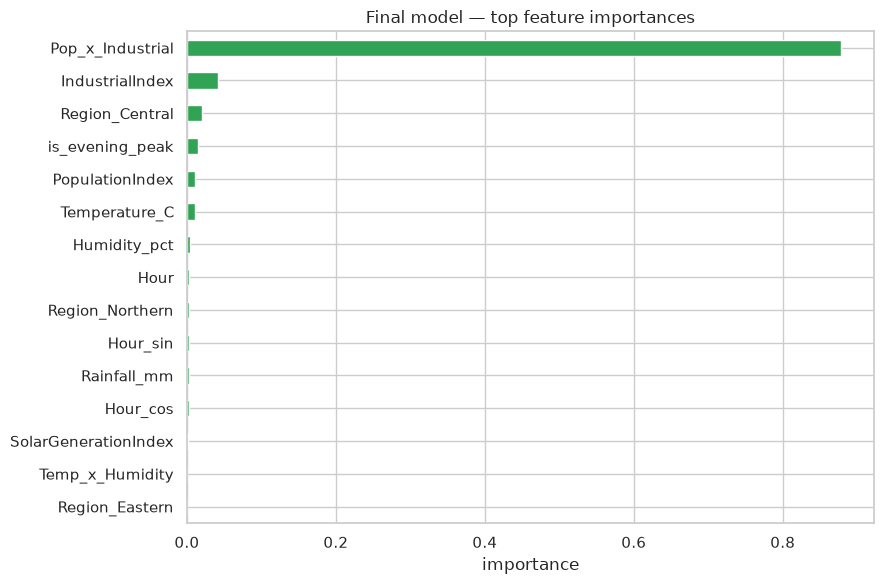

In [7]:
# (c) feature importance
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values().tail(15)
fig, ax = plt.subplots(figsize=(9,6))
imp.plot.barh(ax=ax, color='#31a354'); ax.set_title('Final model — top feature importances')
ax.set_xlabel('importance'); fig.tight_layout()
fig.savefig(FIGS/'final_feature_importance.png', dpi=120); plt.show()

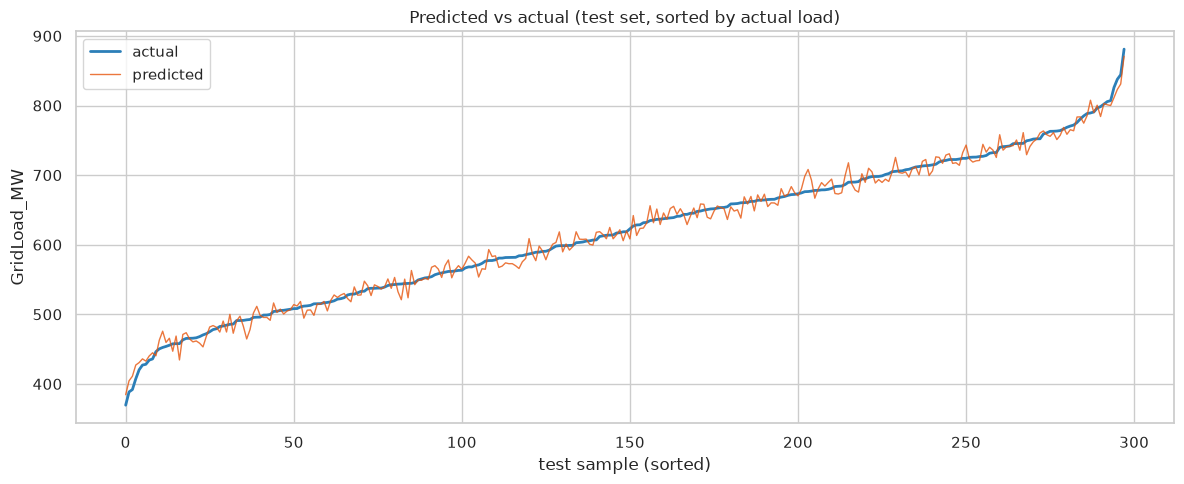

In [8]:
# (d) predicted vs actual over a sample, sorted by load (readability)
order = np.argsort(yte.values)
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(np.array(yte)[order], label='actual', color='#2c7fb8', lw=2)
ax.plot(np.array(pred)[order], label='predicted', color='#e6550d', lw=1, alpha=.8)
ax.set_title('Predicted vs actual (test set, sorted by actual load)')
ax.set_xlabel('test sample (sorted)'); ax.set_ylabel('GridLoad_MW'); ax.legend()
fig.tight_layout(); fig.savefig(FIGS/'final_pred_vs_actual_line.png', dpi=120); plt.show()

## Step 6 — Refit on all data & save as project best model

In [9]:
final = GradientBoostingRegressor(**PARAMS).fit(X, y)
joblib.dump(final, REPO/'best_model'/'best_model.joblib')
pd.Series({'model':'GradientBoosting (tuned, final)', **metrics}).to_csv(REPO/'best_model'/'metrics.csv')
pd.Series(X.columns, name='feature').to_csv(REPO/'best_model'/'feature_names.csv', index=False)
print('Saved final model + metrics + feature names to best_model/')

Saved final model + metrics + feature names to best_model/


## Summary
End-to-end pipeline (raw → clean → engineered features → tuned GradientBoosting) reaches **R² ≈ 0.99, MAPE ≈ 1.4%** on held-out data with a healthy CV score. Every design choice is backed by an experiment notebook (see the table at the top). This is the model shipped in `best_model/best_model.joblib`.